In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv("saber11_bogota_limpio_excel.csv", sep=";")

df.head()

,periodo,cole_area_ubicacion,cole_depto_ubicacion,cole_mcpio_ubicacion,cole_naturaleza,cole_calendario,cole_jornada,cole_caracter,cole_bilingue,cole_genero,...,fami_tienecomputador,punt_global,punt_matematicas,punt_lectura_critica,punt_c_naturales,punt_sociales_ciudadanas,punt_ingles,desemp_ingles,estu_consecutivo,estrato_num
0,20194,urbano,bogota,bogota d.c.,oficial,a,tarde,academico,SIN REGISTRO,mixto,...,SI,278.0,58.0,57.0,59.0,46.0,62.0,a2,sb11201940399505,1.0
1,20152,urbano,bogota,bogota d.c.,no oficial,a,mañana,academico,n,mixto,...,NO,268.0,50.0,50.0,54.0,60.0,54.0,a1,sb11201520544825,2.0
2,20172,urbano,bogota,bogota d.c.,oficial,a,mañana,academico,SIN REGISTRO,mixto,...,NO,328.0,64.0,70.0,61.0,69.0,60.0,a2,sb11201720162770,2.0
3,20142,urbano,bogota,bogota d.c.,oficial,a,tarde,academico,n,mixto,...,SI,331.0,69.0,67.0,66.0,65.0,59.0,a2,sb11201420094691,3.0
4,20162,urbano,bogota,bogota d.c.,oficial,a,mañana,academico,n,mixto,...,SI,306.0,63.0,62.0,62.0,58.0,65.0,a2,sb11201620342593,1.0


In [9]:
df["cole_area_ubicacion"].value_counts()

cole_area_ubicacion
urbano    531758
rural       4857
Name: count, dtype: int64

In [10]:
df.groupby("cole_area_ubicacion")["punt_global"].mean()

cole_area_ubicacion
rural     283.299362
urbano    273.637510
Name: punt_global, dtype: float64

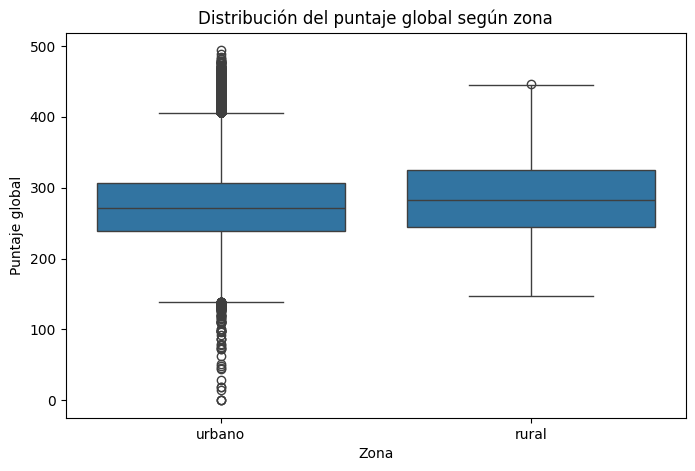

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="cole_area_ubicacion",
    y="punt_global"
)

plt.title("Distribución del puntaje global según zona")
plt.xlabel("Zona")
plt.ylabel("Puntaje global")

plt.show()

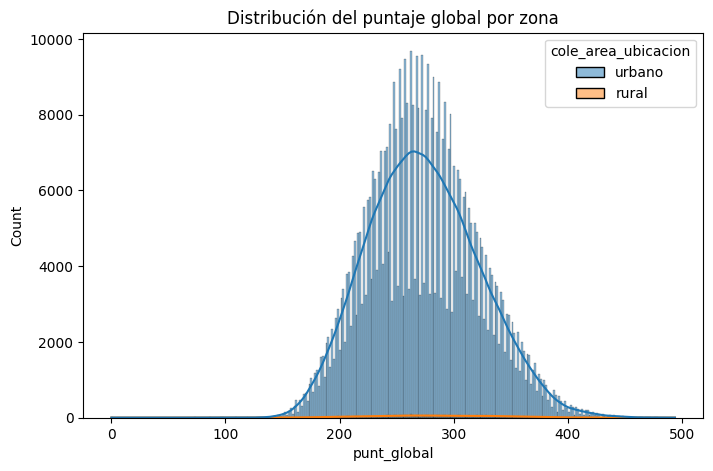

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="punt_global",
    hue="cole_area_ubicacion",
    kde=True
)

plt.title("Distribución del puntaje global por zona")

plt.show()

In [15]:
urbano = df[df["cole_area_ubicacion"]=="urbano"]["punt_global"]

rural = df[df["cole_area_ubicacion"]=="rural"]["punt_global"]

resultado = stats.ttest_ind(urbano, rural)

resultado

TtestResult(statistic=np.float64(-13.772632240959124), pvalue=np.float64(3.787536252837536e-43), df=np.float64(536613.0))

In [16]:
print("Conclusión:")
print("Existen diferencias significativas en el desempeño del ICFES según la zona.")
print("Los estudiantes de zona urbana presentan mejores resultados.")
print("p-value:", resultado.pvalue)

Conclusión:
Existen diferencias significativas en el desempeño del ICFES según la zona.
Los estudiantes de zona urbana presentan mejores resultados.
p-value: 3.787536252837536e-43


In [19]:
df2 = df[df["cole_caracter"].isin(["academico", "tecnico", "tecnico/academico"])]

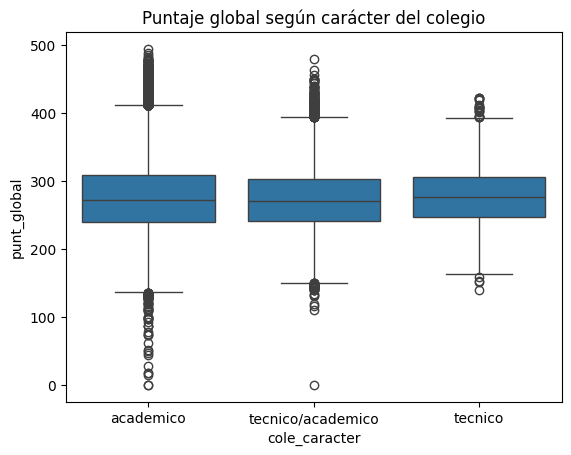

In [21]:
sns.boxplot(
    data=df2,
    x="cole_caracter",
    y="punt_global"
)
plt.title("Puntaje global según carácter del colegio")
plt.show()

In [23]:
df2.groupby(["cole_area_ubicacion", "cole_caracter"])["punt_global"].mean()

cole_area_ubicacion  cole_caracter    
rural                academico            287.753850
                     tecnico              263.044177
                     tecnico/academico    250.660804
urbano               academico            274.537955
                     tecnico              276.692179
                     tecnico/academico    272.049632
Name: punt_global, dtype: float64